# External validation: microsome → hepatocyte clearance

## Why this dataset

Our hypothesis is **"the stronger the source–target label correspondence, the better transfer works"**.
We check with fully independent public data whether the pattern seen in our data (f_u 0.70 / CL 0.19 / t½ 0.05)
**reproduces on a different domain pair**.

| | |
|---|---|
| source | TDC `clearance_microsome_az` — human liver microsome intrinsic clearance |
| target | TDC `clearance_hepatocyte_az` — human hepatocyte intrinsic clearance |
| overlap with our target | **0** (fully independent) |
| molecules shared by the two datasets | **682** |

### What is special about this pair
The CV data of this study have zero source–target overlap by design, so **two labels of the same molecule could not be compared directly**
(hence the 1-NN approximation). Here 682 molecules are shared, so **label correspondence can be measured directly**.

### Prior prediction (recorded before seeing the results)
Both measurements are human-liver-derived in vitro CLint, so label correspondence is expected to be **high**.
If the hypothesis holds, **methods that use the source (PTFT, LCW) should beat target-only** on this pair —
the same pattern as f_u in our data.

> **Caution** — the 682 shared molecules can cause test leakage.
> In each fold, **molecules in the target test set are removed from the source** to prevent it (section 3 below).

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy.stats import pearsonr, spearmanr, ttest_rel

RDLogger.DisableLog('rdApp.*')
ROOT = r'..'
sys.path.insert(0, os.path.join(ROOT, '01_model'))
import proposed_methods as P          # reuse exactly the same models and training loop as this study

P.DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # GPU if available
print('device:', P.DEVICE)

TDC_DIR = os.path.join(ROOT, '0_data_process', 'data')
OUT_DIR = os.path.join(ROOT, 'results', 'external_validation')
os.makedirs(OUT_DIR, exist_ok=True)
N_FOLDS, SEEDS = 5, list(range(10))

pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})

device: cpu


## 1. Loading and preprocessing

Aligned with this study.
- canonicalise SMILES and keep only molecules with a Graphormer embedding
- average values per molecule, then **log10 transform**
- source z-scored over the whole set, target z-scored with **per-fold train statistics** (prevents test leakage)

In [2]:
def load_tdc(name):
    d = pd.read_csv(os.path.join(TDC_DIR, f'{name}.tab'), sep='\t')
    smi_col = 'X' if 'X' in d.columns else 'Drug'
    rows = []
    for s, y in zip(d[smi_col].astype(str), d['Y']):
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        c = Chem.MolToSmiles(m)
        if c in P.SMILES_TO_EMB and y > 0:          # only values with an embedding that can be logged
            rows.append((c, float(y)))
    df = pd.DataFrame(rows, columns=['smiles', 'value']).groupby('smiles', as_index=False)['value'].mean()
    df['log_value'] = np.log10(df['value'])
    return df


src_df = load_tdc('clearance_microsome_az')
tgt_df = load_tdc('clearance_hepatocyte_az')
print(f'source (microsome)  : {len(src_df)} molecules')
print(f'target (hepatocyte) : {len(tgt_df)} molecules')
overlap = sorted(set(src_df.smiles) & set(tgt_df.smiles))
print(f'shared molecules    : {len(overlap)}')

source (microsome)  : 1099  molecules
target (hepatocyte) : 1015  molecules
shared molecules    : 679


## 2. Label correspondence — measured directly

Compute the correlation between the two labels **directly** on the 682 shared molecules.
It can be placed on the same axis as this study's 1-NN approximations (f_u 0.70 / CL 0.19 / t½ 0.05).

Direct label correspondence over 679 shared molecules
  Pearson  r = 0.641 (p=6.9e-80)
  Spearman ρ = 0.641 (p=7.9e-80)

This study (1-NN approximation, Tanimoto ≥ 0.4):  f_u 0.70 | CL 0.19 | t½ 0.05


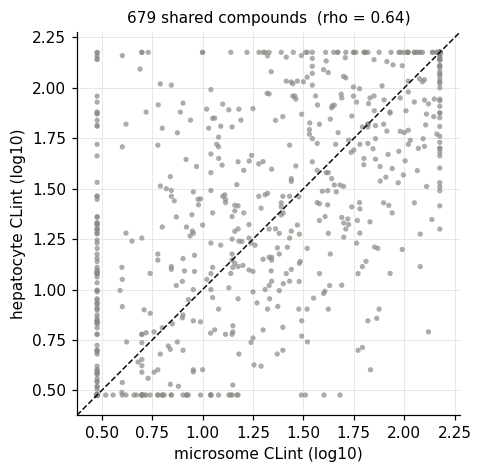

In [3]:
a = src_df.set_index('smiles').loc[overlap, 'log_value']
b = tgt_df.set_index('smiles').loc[overlap, 'log_value']
r_direct, p_r = pearsonr(a, b)
rho_direct, p_rho = spearmanr(a, b)
print(f'Direct label correspondence over {len(overlap)} shared molecules')
print(f'  Pearson  r = {r_direct:.3f} (p={p_r:.1e})')
print(f'  Spearman ρ = {rho_direct:.3f} (p={p_rho:.1e})')
print('\nThis study (1-NN approximation, Tanimoto ≥ 0.4):  f_u 0.70 | CL 0.19 | t½ 0.05')

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(a, b, s=12, color='#8a8984', alpha=0.7, edgecolors='none')
lo, hi = min(a.min(), b.min()) - 0.1, max(a.max(), b.max()) + 0.1
ax.plot([lo, hi], [lo, hi], ls='--', lw=1, color='#0b0b0b')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('microsome CLint (log10)'); ax.set_ylabel('hepatocyte CLint (log10)')
ax.set_title(f'{len(overlap)} shared compounds  (rho = {rho_direct:.2f})', fontsize=10)
plt.tight_layout(); plt.show()

## 3. Scaffold 5-fold split

Same as this study: split the target into 5 folds by Murcko scaffold, then split each fold's train again
80/20 by scaffold to build a validation set.

**Leakage prevention** — in each fold, molecules in that fold's target test set are removed from the source.
(The two datasets share 682 molecules; without removal the source would effectively reveal test labels.)

In [4]:
def scaffold(s):
    m = Chem.MolFromSmiles(s)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else s


tgt_df['scaffold'] = tgt_df['smiles'].map(scaffold)
groups = tgt_df.groupby('scaffold').indices
keys = sorted(groups)
np.random.RandomState(0).shuffle(keys)

fold_of = np.empty(len(tgt_df), dtype=int)          # assign scaffold groups to 5 folds in order of size
sizes = np.zeros(N_FOLDS, dtype=int)
for k in sorted(keys, key=lambda k: -len(groups[k])):
    f = int(np.argmin(sizes))
    fold_of[groups[k]] = f
    sizes[f] += len(groups[k])
tgt_df['fold'] = fold_of
print('Target size per fold:', sizes.tolist())


def build_fold(fold):
    te = tgt_df[tgt_df.fold == fold]
    tr = tgt_df[tgt_df.fold != fold]
    mu, sd = tr['log_value'].mean(), tr['log_value'].std()       # z-score with fold-train statistics

    idx = np.arange(len(tr), dtype='float32')[:, None]
    tr_i, _, va_i, _ = P.split_train_val(idx, ((tr['log_value'] - mu) / sd).to_numpy('float32'),
                                         fold, smiles=tr['smiles'].tolist())
    tr_i, va_i = tr_i[:, 0].astype(int), va_i[:, 0].astype(int)

    src = src_df[~src_df.smiles.isin(set(te.smiles))]            # leakage prevention: remove test molecules
    emb = lambda ss: np.stack([P.SMILES_TO_EMB[s] for s in ss]).astype('float32')
    z = lambda v: ((v - mu) / sd).to_numpy('float32')
    return {
        'src_smiles': src.smiles.tolist(), 'X_src': emb(src.smiles),
        'y_src': ((src.log_value - src.log_value.mean()) / src.log_value.std()).to_numpy('float32'),
        'fit_smiles': tr.smiles.iloc[tr_i].tolist(), 'X_fit': emb(tr.smiles.iloc[tr_i]), 'y_fit': z(tr.log_value.iloc[tr_i]),
        'X_val': emb(tr.smiles.iloc[va_i]), 'y_val': z(tr.log_value.iloc[va_i]),
        'X_test': emb(te.smiles), 'y_test': z(te.log_value),
        'n_src_removed': len(src_df) - len(src),
    }


folds = {f: build_fold(f) for f in range(N_FOLDS)}
d0 = folds[0]
print(f"fold 0: source {len(d0['X_src'])} (leakage removed {d0['n_src_removed']}) | "
      f"fit {len(d0['X_fit'])} val {len(d0['X_val'])} test {len(d0['X_test'])}")

Target size per fold: [203, 203, 203, 203, 203]
fold 0: source 965 (leakage removed 134) | fit 650 val 162 test 203


## 4. Method comparison

Uses exactly the same models and training loop as this study (`proposed_methods.py`).

| Method | Description |
|---|---|
| `TargetOnly` | no source — the reference |
| `MMD` | CMMD with a large σ_y gives k_y ≈ 1, i.e. the **existing marginal MMD** |
| `CMMD` | conditional (proposed) |
| `LCW`, `LCW-rel`, `LCW-corr` | label-correspondence weighting and its decomposition |
| `PTFT` | pretrain the encoder on source labels, then fine-tune on the target |
| `PTFT-shuffled` | control with shuffled source labels — checks whether the gain comes from the labels |

Hyperparameters are re-selected on this data with **the same protocol** as this study (fold-mean val R², seed 0).

In [5]:
GRID = {
    'TargetOnly': [{}],
    'MMD': [{'lam': l, 'sigma_y': 1000.0} for l in (0.1, 0.3, 1.0)],       # large σ_y = marginal
    'CMMD': [{'lam': l, 'sigma_y': s} for l in (0.1, 0.3, 1.0) for s in (0.25, 0.5, 1.0)],
    'LCW': [{'lam': l, 'tau': t} for l in (0.1, 0.3, 1.0) for t in (0.5, 1.0, 2.0)],
    'LCW-rel': [{'lam': l, 'tau': 1.0} for l in (0.1, 0.3, 1.0)],
    'LCW-corr': [{'lam': l, 'tau': t} for l in (0.1, 0.3, 1.0) for t in (0.5, 1.0, 2.0)],
    'PTFT': [{}],
    'PTFT-shuffled': [{'shuffle': True}],
}
BASE = {'MMD': 'CMMD', 'PTFT-shuffled': 'PTFT'}      # run_method name actually called

t0 = time.time()
best_hp = {}
for m, cands in GRID.items():
    if len(cands) == 1:
        best_hp[m] = cands[0]
        continue
    scored = [(np.mean([P.run_method(BASE.get(m, m), folds[f], 'ext', f, 0, hp)['val_r2']
                        for f in range(N_FOLDS)]), hp) for hp in cands]
    scored.sort(key=lambda x: -x[0])
    best_hp[m] = scored[0][1]
    print(f'  [tune] {m:<14} → {scored[0][1]}  val R²={scored[0][0]:.4f}  ({time.time()-t0:.0f}s)', flush=True)
best_hp

~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant

  [tune] MMD            → {'lam': 0.1, 'sigma_y': 1000.0}  val R²=0.1979  (34s)


~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
~\anaconda3\envs\myenv\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant

  [tune] CMMD           → {'lam': 1.0, 'sigma_y': 0.5}  val R²=0.2166  (154s)
  [tune] LCW            → {'lam': 1.0, 'tau': 2.0}  val R²=0.2639  (266s)
  [tune] LCW-rel        → {'lam': 1.0, 'tau': 1.0}  val R²=0.2650  (303s)
  [tune] LCW-corr       → {'lam': 1.0, 'tau': 1.0}  val R²=0.2850  (420s)


{'TargetOnly': {},
 'MMD': {'lam': 0.1, 'sigma_y': 1000.0},
 'CMMD': {'lam': 1.0, 'sigma_y': 0.5},
 'LCW': {'lam': 1.0, 'tau': 2.0},
 'LCW-rel': {'lam': 1.0, 'tau': 1.0},
 'LCW-corr': {'lam': 1.0, 'tau': 1.0},
 'PTFT': {},
 'PTFT-shuffled': {'shuffle': True}}

In [6]:
rows = []
for m, hp in best_hp.items():
    for seed in SEEDS:
        for f in range(N_FOLDS):
            r = P.run_method(BASE.get(m, m), folds[f], 'ext', f, seed, hp)
            rows.append({'method': m, 'seed': seed, 'fold': f, **r})
    sub = pd.DataFrame(rows); sub = sub[sub.method == m]
    print(f'  {m:<14} R²={sub.r2.mean():+.4f} ρ={sub.rho.mean():.4f}  ({time.time()-t0:.0f}s)', flush=True)

runs = pd.DataFrame(rows)
runs.to_csv(os.path.join(OUT_DIR, 'runs.csv'), index=False)
print(f'\nTotal {time.time()-t0:.0f}s')

  TargetOnly     R²=+0.0824 ρ=0.3743  (502s)
  MMD            R²=+0.0907 ρ=0.3783  (643s)
  CMMD           R²=+0.0875 ρ=0.3820  (798s)
  LCW            R²=+0.1088 ρ=0.4130  (937s)
  LCW-rel        R²=+0.1113 ρ=0.4066  (1079s)
  LCW-corr       R²=+0.0946 ρ=0.4108  (1224s)
  PTFT           R²=+0.1178 ρ=0.4071  (1350s)
  PTFT-shuffled  R²=+0.0880 ρ=0.3764  (1483s)

Total 1483s


## 5. Results — vs TargetOnly

Seed mean per fold, then a paired t-test (n = 5 folds). Same test as this study.

In [7]:
fold_mean = runs.groupby(['method', 'fold'])[['r2', 'rho', 'rmse']].mean()
ref = fold_mean.loc['TargetOnly']


def holm(p):
    p = np.asarray(p, float); adj = np.full_like(p, np.nan); run = 0.0
    for k, i in enumerate(np.argsort(p)):
        run = max(run, min(1.0, (len(p) - k) * p[i])); adj[i] = run
    return adj


res = []
for m in best_hp:
    a = fold_mean.loc[m]['r2']
    row = {'method': m, 'R²': a.mean(), 'ρ': fold_mean.loc[m]['rho'].mean()}
    if m != 'TargetOnly':
        d = a - ref['r2']
        se = d.std(ddof=1) / np.sqrt(len(d))
        row.update({'ΔR²': d.mean(), 'CI_lo': d.mean() - 2.776 * se, 'CI_hi': d.mean() + 2.776 * se,
                    'p': ttest_rel(a, ref['r2']).pvalue})
    res.append(row)
res = pd.DataFrame(res)
res.loc[res.method != 'TargetOnly', 'p_holm'] = holm(res.loc[res.method != 'TargetOnly', 'p'])
seed_sd = runs[runs.method == 'TargetOnly'].groupby('seed').r2.mean().std()
res['vs_seed_SD'] = res['ΔR²'] / seed_sd
res.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False, encoding='utf-8-sig')
print(f'TargetOnly seed SD = {seed_sd:.4f}')
res.round(4)

TargetOnly seed SD = 0.0225


,method,R²,ρ,ΔR²,CI_lo,CI_hi,p,p_holm,vs_seed_SD
0,TargetOnly,0.0824,0.3743,NaN,NaN,NaN,NaN,NaN,NaN
1,MMD,0.0907,0.3783,0.0083,-0.0151,0.0316,0.3815,1.0000,0.3680
2,CMMD,0.0875,0.3820,0.0051,-0.0167,0.0269,0.5539,1.0000,0.2258
3,LCW,0.1088,0.4130,0.0264,-0.0037,0.0565,0.0715,0.4292,1.1764
4,LCW-rel,0.1113,0.4066,0.0289,-0.0107,0.0685,0.1125,0.5625,1.2872
5,LCW-corr,0.0946,0.4108,0.0122,-0.0184,0.0428,0.3296,1.0000,0.5441
6,PTFT,0.1178,0.4071,0.0354,-0.0019,0.0727,0.0578,0.4047,1.5765
7,PTFT-shuffled,0.0880,0.3764,0.0056,-0.0075,0.0187,0.2999,1.0000,0.2496


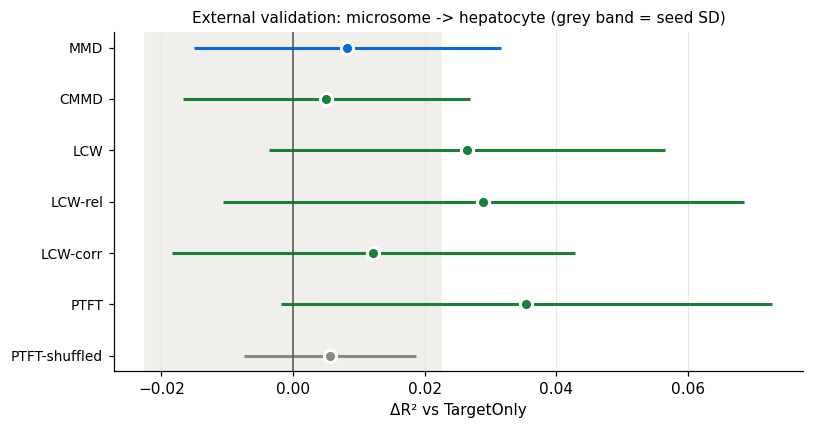

In [8]:
plot_m = [m for m in best_hp if m != 'TargetOnly']
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, m in enumerate(plot_m):
    a = fold_mean.loc[m]['r2']; d = a - ref['r2']
    se = d.std(ddof=1) / np.sqrt(len(d)); y = len(plot_m) - 1 - i
    c = '#8a8984' if m.endswith('shuffled') else ('#0969da' if m == 'MMD' else '#1a7f37')
    ax.hlines(y, d.mean() - 2.776 * se, d.mean() + 2.776 * se, color=c, lw=2)
    ax.plot(d.mean(), y, 'o', ms=8, color=c, mec='white', mew=2)
ax.axvline(0, color='#52514e', lw=1)
ax.axvspan(-seed_sd, seed_sd, color='#f0efec', zorder=0)
ax.set_yticks(range(len(plot_m))); ax.set_yticklabels(plot_m[::-1], fontsize=9)
ax.set_xlabel('ΔR² vs TargetOnly'); ax.grid(axis='y', visible=False)
ax.set_title('External validation: microsome -> hepatocyte (grey band = seed SD)', fontsize=10)
plt.tight_layout(); plt.show()

## 6. Contrast with this study

The prior prediction was **"label correspondence is high, so methods using the source should work"**.
The table below places this pair's results on the same axis as the three endpoints of this study.

In [9]:
prop_final = os.path.join(ROOT, 'results', 'proposed', 'runs_final.csv')
rowsc = [{'dataset': 'microsome → hepatocyte (external)', 'label correspondence': round(rho_direct, 2),
          'measurement': 'direct (682 shared)',
          **{m: round(res.set_index('method').loc[m, 'ΔR²'], 4) for m in ('PTFT', 'LCW', 'CMMD') if m in res.method.values}}]
if os.path.exists(prop_final):
    pf = pd.read_csv(prop_final)
    NN = {'fu': 0.70, 'clearance': 0.19, 'half_life': 0.05}
    LAB = {'fu': 'f_u (this study)', 'clearance': 'CL (this study)', 'half_life': 't½ (this study)'}
    for p in ('fu', 'clearance', 'half_life'):
        base = pf[(pf.method == 'TargetOnly') & (pf.property == p)].groupby('fold').r2.mean()
        row = {'dataset': LAB[p], 'label correspondence': NN[p], 'measurement': '1-NN approximation'}
        for m in ('PTFT', 'LCW', 'CMMD'):
            if m in pf.method.unique():
                row[m] = round((pf[(pf.method == m) & (pf.property == p)].groupby('fold').r2.mean() - base).mean(), 4)
        rowsc.append(row)
compare = pd.DataFrame(rowsc)
display(compare)
print('\nHypothesis: the higher the label correspondence, the larger ΔR² should be.')

,dataset,label correspondence,measurement,PTFT,LCW,CMMD
0,microsome → hepatocyte (external),0.64,direct (682 shared),0.0354,0.0264,0.0051
1,f_u (this study),0.70,1-NN approximation,0.0749,0.0202,0.0185
2,CL (this study),0.19,1-NN approximation,-0.0190,-0.0032,-0.0162
3,t½ (this study),0.05,1-NN approximation,0.0049,0.0007,0.0110



Hypothesis: the higher the label correspondence, the larger ΔR² should be.


## 7. Caveats for interpretation

1. **Different measurement methods** — this pair's correspondence is the **direct** correlation over 682 shared molecules,
   while this study's values are **1-NN approximations** using structural neighbours. Place them on the same axis, but do not treat the numbers as identical.
2. **Both domains are in vitro** — an easier setting than this study's in vitro → in vivo.
   Working here does not guarantee transfer to in vivo.
3. **Effect of overlap removal** — test molecules were removed from the source in each fold (see the section 3 output for counts).
   The source shrinks accordingly, so source use is disadvantaged compared with this study, which has no overlap.
4. **Power** — n for the paired test is 5 folds. The same limitation as this study applies.